In [1]:
# ====================================================================
# SECTION 0: IMPORTS & SETUP
# ====================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import unicodedata
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from transformers import AutoTokenizer, AutoModel
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv

from pythainlp.tokenize import word_tokenize
from pythainlp.corpus import thai_stopwords

import matplotlib.pyplot as plt
import seaborn as sns

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cpu


In [2]:
# ====================================================================
# SECTION 1: DATA LOADING & PREPROCESSING
# ====================================================================
print("\nSECTION 1: DATA LOADING & PREPROCESSING")

# Load dataset
df = pd.read_csv("AFNC_news_dataset_tf-2.csv")
df = df.reset_index(drop=True)
print(f"✅ Dataset loaded: {len(df)} records")

# Define label mapping
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}


SECTION 1: DATA LOADING & PREPROCESSING
✅ Dataset loaded: 11111 records


In [3]:
# ====================================================================
# SECTION 2: TEXT NORMALIZATION & ENCODING
# ====================================================================
print("\nSECTION 2: TEXT NORMALIZATION & ENCODING")

# Thai text normalization
ZW = ''.join(['\u200B', '\u200C', '\u200D', '\uFEFF'])

def normalize_thai(s):
    """Normalize Thai text: remove zero-width chars, normalize unicode, remove duplicates."""
    if pd.isna(s):
        return None
    s = str(s).replace('\u00A0', ' ').translate({ord(ch): None for ch in ZW})
    s = unicodedata.normalize('NFC', s)
    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'([\u0E31\u0E34-\u0E3A\u0E47-\u0E4E])\1+', r'\1', s)
    return s

# Clean and normalize
df['ประเภทข่าว']     = df['ประเภทข่าว'].astype(str).str.strip()
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].astype(str).str.strip()
df = df[~df['ประเภทข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df[~df['หมวดหมู่ของข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df.dropna(subset=['หัวข้อข่าว', 'ประเภทข่าว', 'หมวดหมู่ของข่าว']).reset_index(drop=True)

# Normalize Thai text
df['ประเภทข่าว']     = df['ประเภทข่าว'].apply(normalize_thai)
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].apply(normalize_thai)

# Label encoding
df['label_id'] = df['ประเภทข่าว'].map(label2id)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

# Category encoding
cats   = sorted(df['หมวดหมู่ของข่าว'].unique())
cat2id = {c: i for i, c in enumerate(cats)}
id2cat = {i: c for c, i in cat2id.items()}
df['category_id'] = df['หมวดหมู่ของข่าว'].map(cat2id)

print(f"✅ Labels: {label2id}")
print(f"✅ Categories: {len(cats)} หมวดหมู่")


SECTION 2: TEXT NORMALIZATION & ENCODING
✅ Labels: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
✅ Categories: 8 หมวดหมู่


In [4]:
# ====================================================================
# SECTION 3: DATASET BALANCING
# ====================================================================
print("\nSECTION 3: DATASET BALANCING")

df_true = df[df['label_id'] == 0]
df_fake = df[df['label_id'] == 1]
print(f"Before balance: จริง = {len(df_true)}, ปลอม = {len(df_fake)}")

# Balance by undersampling to minority class
min_len          = min(len(df_true), len(df_fake))
df_true_sampled  = df_true.sample(n=min_len, random_state=42)
df_fake_sampled  = df_fake.sample(n=min_len, random_state=42)
df_balanced      = pd.concat([df_true_sampled, df_fake_sampled]) \
                     .sample(frac=1, random_state=42).reset_index(drop=True)

N_balanced     = len(df_balanced)
y_balanced     = df_balanced['label_id'].values
y_cat_balanced = df_balanced['category_id'].values
texts_balanced = df_balanced['หัวข้อข่าว'].fillna("").astype(str).tolist()

print(f"✅ After balance (total {N_balanced} news):")
print(df_balanced['ประเภทข่าว'].value_counts())


SECTION 3: DATASET BALANCING
Before balance: จริง = 2872, ปลอม = 8237
✅ After balance (total 5744 news):
ประเภทข่าว
ข่าวจริง    2872
ข่าวปลอม    2872
Name: count, dtype: int64


In [ ]:
# ====================================================================
# [DUPLICATE CODE - REMOVED]
# This cell contained duplicate Thai text normalization code
# that was already handled in Section 2.
# Removal: Code cleanup for better maintainability
# ====================================================================
pass

✅ Category Classes (8 หมวดหมู่)


In [ ]:
# ====================================================================
# [DUPLICATE CODE - REMOVED]
# This cell contained duplicate dataset balancing code
# that was already handled in Section 3.
# Removal: Code cleanup for better maintainability
# ====================================================================
pass


📊 Before balance: จริง = 2872, ปลอม = 8237
⚖️  After balance (total 5744 news):
ประเภทข่าว
ข่าวจริง    2872
ข่าวปลอม    2872
Name: count, dtype: int64
✅ N_balanced: 5744


In [7]:
# ====================================================================
# SECTION 4: LOAD EMBEDDING MODELS
# ====================================================================
print("\nSECTION 4: LOAD EMBEDDING MODELS")

# WangchanBERTa
model_wcb  = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_wcb, use_fast=False)
lm_model   = AutoModel.from_pretrained(model_wcb).to(device).eval()
print(f"✅ WangchanBERTa loaded")

# XLM-RoBERTa (for baseline)
model_xlm_name = "xlm-roberta-base"
tokenizer_xlm  = AutoTokenizer.from_pretrained(model_xlm_name)
model_xlm      = AutoModel.from_pretrained(model_xlm_name).to(device).eval()
print(f"✅ XLM-RoBERTa loaded")


SECTION 4: LOAD EMBEDDING MODELS
✅ WangchanBERTa loaded
✅ XLM-RoBERTa loaded


In [8]:
# ====================================================================
# SECTION 5: BERT EMBEDDING FUNCTION
# ====================================================================
@torch.no_grad()
def get_bert_embeddings_batch(
    texts, tokenizer, model, device,
    max_length=256, batch_size=32, use_mean_pool=True
):
    """Generate BERT embeddings as normalized numpy array (N, hidden_size)."""
    model.eval()
    all_embeddings = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        batch_texts = [
            "" if (isinstance(t, float) and np.isnan(t)) else str(t)
            for t in batch_texts
        ]
        inputs = tokenizer(
            batch_texts,
            truncation=True, padding=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        outputs     = model(**inputs)
        last_hidden = outputs.last_hidden_state

        if use_mean_pool:
            attn   = inputs['attention_mask'].unsqueeze(-1)
            summed = (last_hidden * attn).sum(dim=1)
            denom  = attn.sum(dim=1).clamp(min=1)
            emb    = (summed / denom).cpu().numpy()
        else:
            emb = last_hidden[:, 0, :].cpu().numpy()

        all_embeddings.append(emb)

    return np.vstack(all_embeddings)

In [9]:
# ====================================================================
# SECTION 6: GENERATE WANGCHANBERTA EMBEDDINGS
# ====================================================================
print("\nSECTION 6: GENERATE WANGCHANBERTA EMBEDDINGS")

content_emb = get_bert_embeddings_batch(
    texts_balanced,
    tokenizer=tokenizer, model=lm_model,
    device=device, max_length=256, batch_size=32, use_mean_pool=True
)
x_balanced = normalize(content_emb, axis=1, norm='l2')
print(f"✅ Embeddings generated: shape {x_balanced.shape}")


SECTION 6: GENERATE WANGCHANBERTA EMBEDDINGS
✅ Embeddings generated: shape (5744, 768)


In [10]:
# ====================================================================
# SECTION 7: DATA SAMPLE VERIFICATION
# ====================================================================
print("\nSECTION 7: SAMPLE DATA VERIFICATION")

print("\nSample of true news:")
print(df_balanced[df_balanced['label_id'] == 0][['หัวข้อข่าว', 'label_id']].head(2))
print("\nSample of fake news:")
print(df_balanced[df_balanced['label_id'] == 1][['หัวข้อข่าว', 'label_id']].head(2))


SECTION 7: SAMPLE DATA VERIFICATION

Sample of true news:
                                          หัวข้อข่าว  label_id
0  หลังจากหย่าผู้ชายสามารถจดทะเบียนสมรสต่อได้ทันท...         0
5  ศูนย์ฉีดวัคซีนกลางบางซื่อ เปิดจองคิวฉีดเข็ม 3 ...         0

Sample of fake news:
                                          หัวข้อข่าว  label_id
1   ผลิตภัณฑ์ยาแคปซูลกระชาย ช่วยบำรุงหัวใจ และมีฤ...         1
2  PTT ส่ง SMS แจ้งผู้ใช้บริการ ให้แลกคะแนนสะสมผ่...         1



SECTION 8: DATA DISTRIBUTION VISUALIZATION


C:\Users\Infinix\AppData\Local\Temp\ipykernel_17424\3478258106.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


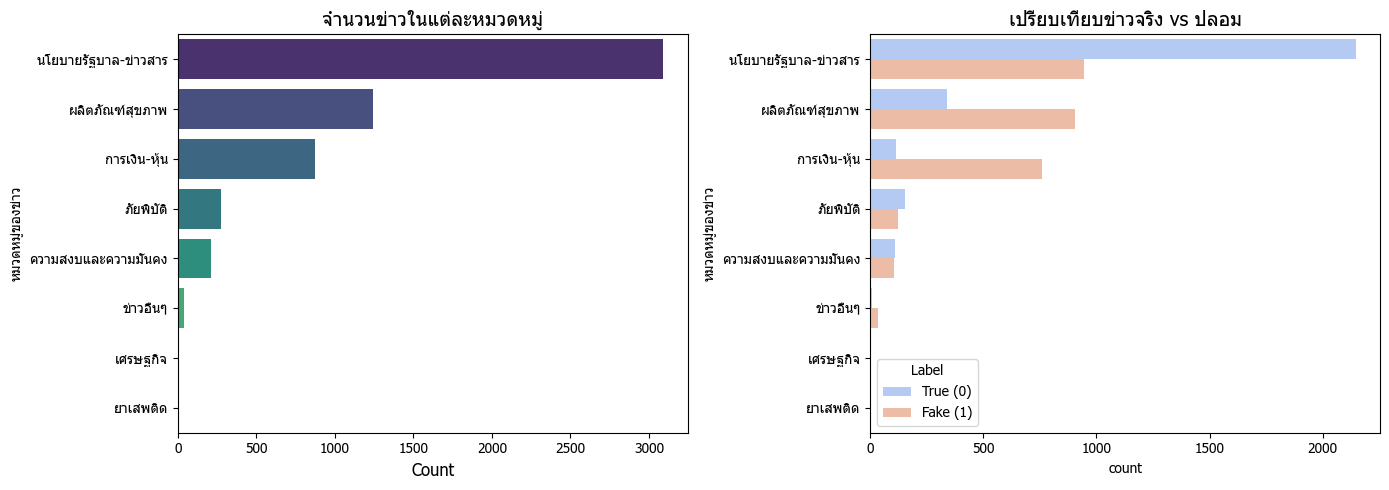

✅ Distribution plots displayed


In [11]:
# ====================================================================
# SECTION 8: DATA DISTRIBUTION VISUALIZATION
# ====================================================================
print("\nSECTION 8: DATA DISTRIBUTION VISUALIZATION")

try:
    plt.rcParams['font.family'] = 'Tahoma'
except Exception:
    pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution by category
sns.countplot(
    y=df_balanced['หมวดหมู่ของข่าว'],
    order=df_balanced['หมวดหมู่ของข่าว'].value_counts().index,
    palette='viridis', ax=axes[0]
)
axes[0].set_title('จำนวนข่าวในแต่ละหมวดหมู่', fontsize=14)
axes[0].set_xlabel('Count', fontsize=12)

# True vs Fake per category
sns.countplot(
    data=df_balanced,
    y='หมวดหมู่ของข่าว',
    hue='label_id',
    order=df_balanced['หมวดหมู่ของข่าว'].value_counts().index,
    palette='coolwarm', ax=axes[1]
)
axes[1].set_title('เปรียบเทียบข่าวจริง vs ปลอม', fontsize=14)
axes[1].legend(title='Label', labels=['True (0)', 'Fake (1)'])

plt.tight_layout()
plt.show()
print("✅ Distribution plots displayed")

In [12]:
# ====================================================================
# SECTION 9: BUILD SEMANTIC GRAPH
# ====================================================================
print("\nSECTION 9: BUILD SEMANTIC GRAPH")

k    = 10
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
nbrs.fit(x_balanced)
distances, indices = nbrs.kneighbors(x_balanced)

edges   = []
weights = []

for i in range(N_balanced):
    for j_idx in range(1, k + 1):
        j   = indices[i][j_idx]
        sim = 1 - distances[i][j_idx]
        edges.append([i, j])
        weights.append(sim)

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(weights, dtype=torch.float)

print(f"✅ Graph Built: {N_balanced} nodes, {edge_index.shape[1]} edges")


SECTION 9: BUILD SEMANTIC GRAPH
✅ Graph Built: 5744 nodes, 57440 edges


In [13]:
# ====================================================================
# SECTION 10: TRAIN/VAL/TEST SPLIT
# ====================================================================
print("\nSECTION 10: TRAIN/VAL/TEST SPLIT")

x_tensor = torch.tensor(x_balanced, dtype=torch.float)
y_tensor = torch.tensor(y_balanced,  dtype=torch.long)
idx_all     = np.arange(N_balanced)

idx_train, idx_temp = train_test_split(
    idx_all, test_size=0.30, stratify=y_balanced, random_state=42
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y_balanced[idx_temp], random_state=42
)

train_mask = torch.zeros(N_balanced, dtype=torch.bool); train_mask[idx_train] = True
val_mask   = torch.zeros(N_balanced, dtype=torch.bool); val_mask[idx_val]     = True
test_mask  = torch.zeros(N_balanced, dtype=torch.bool); test_mask[idx_test]   = True

data_graph = Data(
    x          = x_tensor,
    y          = y_tensor,
    edge_index = edge_index,
    edge_attr  = edge_weight.float(),
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
).to(device)

print(f"✅ Data split: Train {train_mask.sum().item()} | Val {val_mask.sum().item()} | Test {test_mask.sum().item()}")


SECTION 10: TRAIN/VAL/TEST SPLIT
✅ Data split: Train 4020 | Val 862 | Test 862


In [14]:
# ====================================================================
# SECTION 11: GRAPH NEURAL NETWORK MODELS (GCN & GAT)
# ====================================================================
print("\nSECTION 11: GRAPH NEURAL NETWORK MODELS")

class GCNNet(nn.Module):
    """Graph Convolutional Network for fake news detection."""
    def __init__(self, num_node_features, num_classes, hidden_channels=256, dropout_rate=0.3):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_weight = getattr(data, 'edge_attr', None)
        
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x


class GATNet(nn.Module):
    """Graph Attention Network for fake news detection.
    
    Note: GAT computes attention weights from node features only.
    It does not support edge attributes/weights like GCNConv does.
    Edge weights are learned through multi-head attention mechanism.
    """
    def __init__(self, num_node_features, num_classes, hidden_channels=256, num_heads=4, dropout_rate=0.3):
        super().__init__()
        self.att1 = GATConv(num_node_features, hidden_channels, heads=num_heads, dropout=dropout_rate)
        self.att2 = GATConv(hidden_channels * num_heads, num_classes, heads=1, dropout=dropout_rate, concat=False)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # GATConv computes attention weights from node features, not edge attributes
        x = self.att1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.att2(x, edge_index)
        return x


def train_gnn_model(model, data, epochs=200, lr=0.001, weight_decay=5e-4):
    """Train a GNN model and return history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            pred_train = out[data.train_mask].argmax(dim=1)
            train_acc = (pred_train == data.y[data.train_mask]).float().mean().item()
            history['train_loss'].append(loss.item())
            history['train_acc'].append(train_acc)
        
        # Validation
        model.eval()
        with torch.no_grad():
            pred = model(data).argmax(dim=1)
            val_acc = (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
            history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        if epoch % 40 == 0:
            print(f"   Epoch {epoch:03d}: Loss {loss.item():.4f} | Train {train_acc:.4f} | Val {val_acc:.4f}")
    
    return model, history


# Train GCN
print("\n🔄 Training GCN Model...")
model_gcn = GCNNet(data_graph.num_features, 2, hidden_channels=256).to(device)
model_gcn, history_gcn = train_gnn_model(model_gcn, data_graph, epochs=200)
print("✅ GCN Training Complete")

# Train GAT
print("\n🔄 Training GAT Model...")
model_gat = GATNet(data_graph.num_features, 2, hidden_channels=256, num_heads=4).to(device)
model_gat, history_gat = train_gnn_model(model_gat, data_graph, epochs=200)
print("✅ GAT Training Complete")


SECTION 11: GRAPH NEURAL NETWORK MODELS

🔄 Training GCN Model...
   Epoch 040: Loss 0.3787 | Train 0.8249 | Val 0.8260
   Epoch 080: Loss 0.3287 | Train 0.8525 | Val 0.8527
   Epoch 120: Loss 0.3071 | Train 0.8679 | Val 0.8527
   Epoch 160: Loss 0.2952 | Train 0.8751 | Val 0.8573
   Epoch 200: Loss 0.2867 | Train 0.8789 | Val 0.8561
✅ GCN Training Complete

🔄 Training GAT Model...
   Epoch 040: Loss 0.3712 | Train 0.8341 | Val 0.8411
   Epoch 080: Loss 0.3341 | Train 0.8557 | Val 0.8573
   Epoch 120: Loss 0.3176 | Train 0.8609 | Val 0.8457
   Epoch 160: Loss 0.3023 | Train 0.8716 | Val 0.8422
   Epoch 200: Loss 0.3011 | Train 0.8692 | Val 0.8469
✅ GAT Training Complete



SECTION 12: TRAINING VISUALIZATION


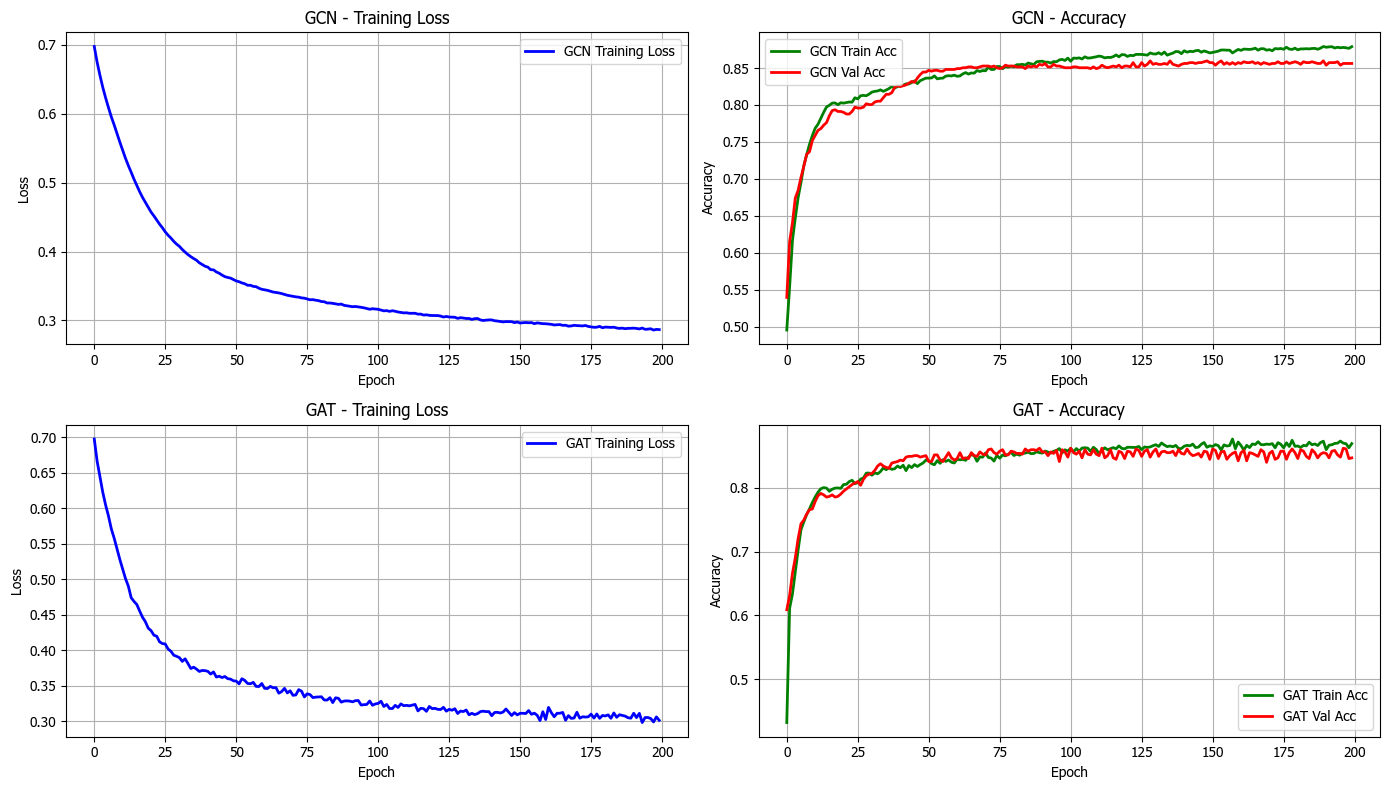

In [15]:
# ====================================================================
# SECTION 12: TRAINING VISUALIZATION
# ====================================================================
print("\nSECTION 12: TRAINING VISUALIZATION")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# GCN Loss
axes[0, 0].plot(history_gcn['train_loss'], label='GCN Training Loss', color='blue', linewidth=2)
axes[0, 0].set_title('GCN - Training Loss', fontsize=12)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True)

# GCN Accuracy
axes[0, 1].plot(history_gcn['train_acc'], label='GCN Train Acc', color='green', linewidth=2)
axes[0, 1].plot(history_gcn['val_acc'], label='GCN Val Acc', color='red', linewidth=2)
axes[0, 1].set_title('GCN - Accuracy', fontsize=12)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True)

# GAT Loss
axes[1, 0].plot(history_gat['train_loss'], label='GAT Training Loss', color='blue', linewidth=2)
axes[1, 0].set_title('GAT - Training Loss', fontsize=12)
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(); axes[1, 0].grid(True)

# GAT Accuracy
axes[1, 1].plot(history_gat['train_acc'], label='GAT Train Acc', color='green', linewidth=2)
axes[1, 1].plot(history_gat['val_acc'], label='GAT Val Acc', color='red', linewidth=2)
axes[1, 1].set_title('GAT - Accuracy', fontsize=12)
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
# ====================================================================
# SECTION 13: EVALUATE GNN MODELS ON TEST SET
# ====================================================================
print("\nSECTION 13: EVALUATE GNN MODELS ON TEST SET")

def evaluate_model(model, data, model_name):
    """Evaluate model on test set."""
    model.eval()
    with torch.no_grad():
        out = model(data)
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
    
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{model_name} Results:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=['True', 'Fake'], digits=4))
    
    return {'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1}

gcn_results = evaluate_model(model_gcn, data_graph, "GCN")
gat_results = evaluate_model(model_gat, data_graph, "GAT")


SECTION 13: EVALUATE GNN MODELS ON TEST SET

GCN Results:
  Accuracy:  0.8666
  Precision: 0.8670
  Recall:    0.8666
  F1-Score:  0.8665
              precision    recall  f1-score   support

        True     0.8798    0.8492    0.8642       431
        Fake     0.8543    0.8840    0.8689       431

    accuracy                         0.8666       862
   macro avg     0.8670    0.8666    0.8665       862
weighted avg     0.8670    0.8666    0.8665       862


GAT Results:
  Accuracy:  0.8619
  Precision: 0.8620
  Recall:    0.8619
  F1-Score:  0.8619
              precision    recall  f1-score   support

        True     0.8645    0.8585    0.8615       431
        Fake     0.8594    0.8654    0.8624       431

    accuracy                         0.8619       862
   macro avg     0.8620    0.8619    0.8619       862
weighted avg     0.8620    0.8619    0.8619       862



In [17]:
# ====================================================================
# SECTION 14: BASELINE MODELS FOR COMPARISON
# ====================================================================
print("\nSECTION 14: TRAIN BASELINE MODELS")

# Prepare data for baselines
y_train_base = y_balanced[idx_train]
y_test_base = y_balanced[idx_test]
train_texts = [texts_balanced[i] for i in idx_train]
test_texts = [texts_balanced[i] for i in idx_test]

# Prepare embeddings
X_train_wcb = x_balanced[idx_train]
X_test_wcb = x_balanced[idx_test]

# Baseline 1: TF-IDF + Logistic Regression
print("\n🔄 Baseline 1: TF-IDF + Logistic Regression...")

def thai_tokenizer(text):
    return word_tokenize(text, engine='newmm', keep_whitespace=False)

tfidf = TfidfVectorizer(tokenizer=thai_tokenizer, max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)

clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train_base)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

baseline1_results = {
    'Accuracy': accuracy_score(y_test_base, y_pred_tfidf),
    'Precision': precision_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    'F1': f1_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
}
print("✅ Done")

# Baseline 2: WangchanBERTa + Random Forest
print("\n🔄 Baseline 2: WangchanBERTa + Random Forest...")

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train_wcb, y_train_base)
y_pred_wcb_rf = clf_rf.predict(X_test_wcb)

baseline2_results = {
    'Accuracy': accuracy_score(y_test_base, y_pred_wcb_rf),
    'Precision': precision_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    'F1': f1_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
}
print("✅ Done")

# Baseline 3: XLM-RoBERTa + Logistic Regression
print("\n🔄 Baseline 3: XLM-RoBERTa + Logistic Regression...")

xlm_emb = get_bert_embeddings_batch(
    texts_balanced, tokenizer=tokenizer_xlm, model=model_xlm,
    device=device, max_length=256, batch_size=32, use_mean_pool=True
)
xlm_emb_norm = normalize(xlm_emb, axis=1, norm='l2')

X_train_xlm = xlm_emb_norm[idx_train]
X_test_xlm = xlm_emb_norm[idx_test]

clf_xlm = LogisticRegression(max_iter=1000, random_state=42)
clf_xlm.fit(X_train_xlm, y_train_base)
y_pred_xlm = clf_xlm.predict(X_test_xlm)

baseline3_results = {
    'Accuracy': accuracy_score(y_test_base, y_pred_xlm),
    'Precision': precision_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    'F1': f1_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
}
print("✅ Done")


SECTION 14: TRAIN BASELINE MODELS

🔄 Baseline 1: TF-IDF + Logistic Regression...


c:\Users\Infinix\OneDrive\เอกสาร\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


✅ Done

🔄 Baseline 2: WangchanBERTa + Random Forest...
✅ Done

🔄 Baseline 3: XLM-RoBERTa + Logistic Regression...
✅ Done



SECTION 15: PERFORMANCE COMPARISON

📊 PERFORMANCE COMPARISON TABLE
                  Accuracy  Precision  Recall      F1
GCN (WCB+Graph)     0.8666     0.8670  0.8666  0.8665
GAT (WCB+Graph)     0.8619     0.8620  0.8619  0.8619
TF-IDF + LR         0.9269     0.9304  0.9269  0.9268
WCB + RF            0.8608     0.8623  0.8608  0.8606
XLM-RoBERTa + LR    0.8155     0.8158  0.8155  0.8155


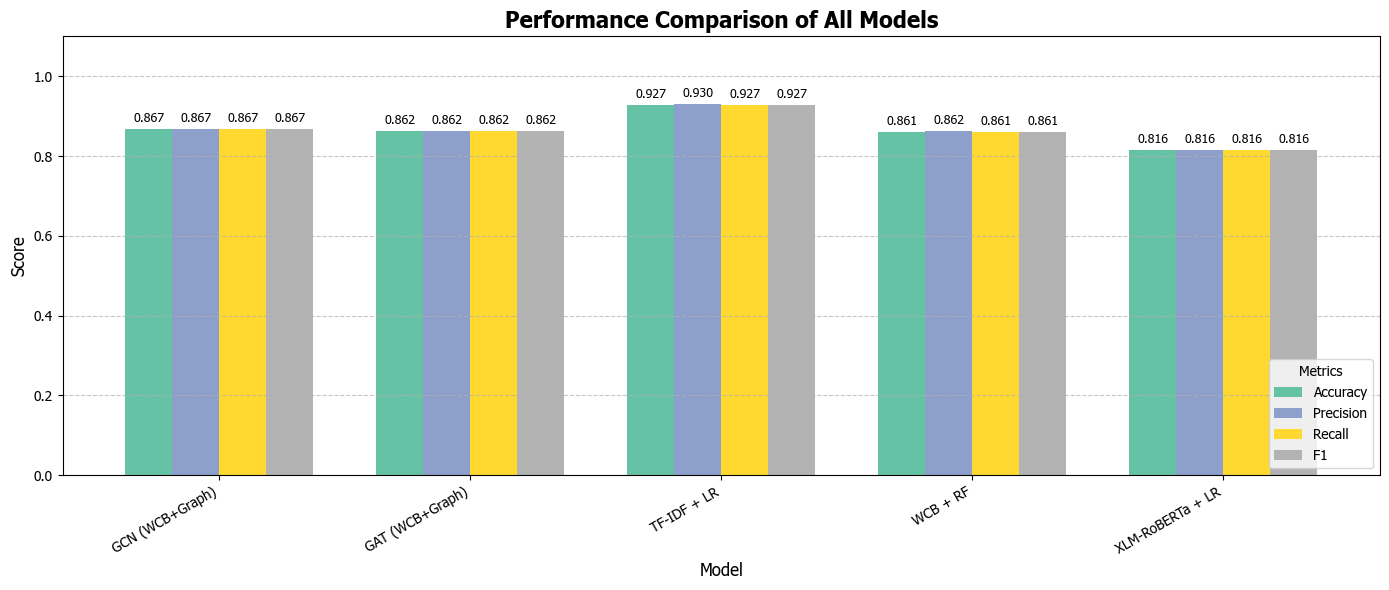


✅ Comparison complete!


In [18]:
# ====================================================================
# SECTION 15: PERFORMANCE COMPARISON TABLE & VISUALIZATION
# ====================================================================
print("\nSECTION 15: PERFORMANCE COMPARISON")

# Combine all results
all_results = {
    'GCN (WCB+Graph)': gcn_results,
    'GAT (WCB+Graph)': gat_results,
    'TF-IDF + LR': baseline1_results,
    'WCB + RF': baseline2_results,
    'XLM-RoBERTa + LR': baseline3_results,
}

# Create comparison dataframe
df_comparison = pd.DataFrame(all_results).T
df_comparison = df_comparison[['Accuracy', 'Precision', 'Recall', 'F1']]

print("\n" + "="*80)
print("📊 PERFORMANCE COMPARISON TABLE")
print("="*80)
print(df_comparison.round(4).to_string())
print("="*80)

# Visualization: Bar plot
fig, ax = plt.subplots(figsize=(14, 6))
df_comparison.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Performance Comparison of All Models', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Metrics', loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Comparison complete!")


SECTION 16: CONFUSION MATRICES


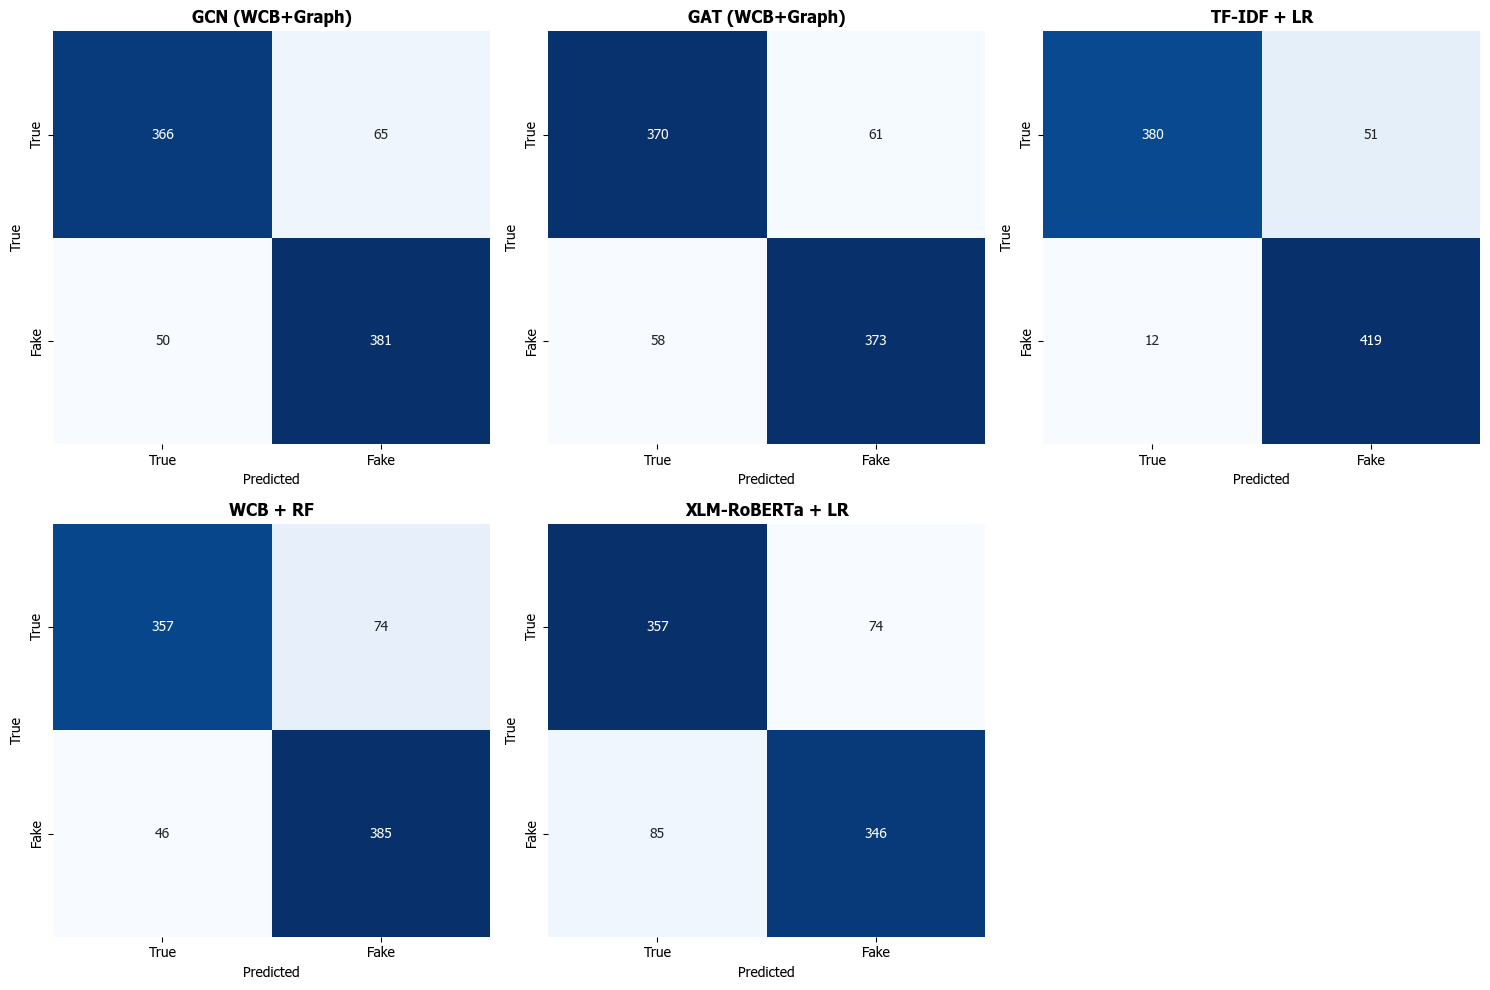

✅ Confusion matrices displayed


In [19]:
# ====================================================================
# SECTION 16: CONFUSION MATRICES FOR ALL MODELS
# ====================================================================
print("\nSECTION 16: CONFUSION MATRICES")

# Get predictions for all models
with torch.no_grad():
    out_gcn = model_gcn(data_graph)
    y_true_gnn = data_graph.y[data_graph.test_mask].cpu().numpy()
    y_pred_gcn_test = out_gcn[data_graph.test_mask].argmax(dim=1).cpu().numpy()
    
    out_gat = model_gat(data_graph)
    y_pred_gat_test = out_gat[data_graph.test_mask].argmax(dim=1).cpu().numpy()

class_names = ['True', 'Fake']
model_predictions = [
    ('GCN (WCB+Graph)', y_true_gnn, y_pred_gcn_test),
    ('GAT (WCB+Graph)', y_true_gnn, y_pred_gat_test),
    ('TF-IDF + LR', y_test_base, y_pred_tfidf),
    ('WCB + RF', y_test_base, y_pred_wcb_rf),
    ('XLM-RoBERTa + LR', y_test_base, y_pred_xlm),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (mname, yt, yp) in enumerate(model_predictions):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[idx].set_title(mname, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('True', fontsize=10)

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Confusion matrices displayed")

In [20]:
# ====================================================================
# SECTION 17: ERROR ANALYSIS - GCN MISCLASSIFIED SAMPLES
# ====================================================================
print("\nSECTION 17: ERROR ANALYSIS")

# Get test indices and texts
test_indices = np.where(data_graph.test_mask.cpu().numpy())[0]
test_texts_gnn = [texts_balanced[i] for i in test_indices]

misclassified = []
for i in range(len(y_true_gnn)):
    if y_true_gnn[i] != y_pred_gcn_test[i]:
        error_type = "FP (True→Fake)" if y_pred_gcn_test[i] == 1 else "FN (Fake→True)"
        misclassified.append({
            'text': test_texts_gnn[i],
            'true': id2label[y_true_gnn[i]],
            'pred': id2label[y_pred_gcn_test[i]],
            'type': error_type
        })

print(f"Total misclassified by GCN: {len(misclassified)} out of {len(y_true_gnn)}")
print(f"\nShowing first 10 misclassified samples:")
print("-" * 70)

for idx, item in enumerate(misclassified[:10]):
    print(f"\n[{idx+1}] {item['type']}")
    print(f"Text: {item['text'][:80]}...")
    print(f"True: {item['true']} | Predicted: {item['pred']}")

print("\n✅ Error analysis complete")


SECTION 17: ERROR ANALYSIS
Total misclassified by GCN: 115 out of 862

Showing first 10 misclassified samples:
----------------------------------------------------------------------

[1] FN (Fake→True)
Text:  รถโดยสารประจำทางที่ใช้ป้ายวิ่งด้วยระบบไฟฟ้าถือว่าผิดกฎหมาย...
True: ข่าวปลอม | Predicted: ข่าวจริง

[2] FP (True→Fake)
Text: กทม. ประกาศสิ้นสุดสาธารณภัยในเขตพื้นที่ก่อสร้างอาคาร สตง....
True: ข่าวจริง | Predicted: ข่าวปลอม

[3] FP (True→Fake)
Text: พื้นที่บ้านหนองจาน จ.สระแก้ว อยู่ในเขตประเทศไทย...
True: ข่าวจริง | Predicted: ข่าวปลอม

[4] FP (True→Fake)
Text: 10 ผักพื้นบ้าน ช่วยบำรุงสมอง ชะลอความแก่ จริงหรือ?...
True: ข่าวจริง | Predicted: ข่าวปลอม

[5] FN (Fake→True)
Text: รองนายกรัฐมนตรี สั่งให้ทหารถอนกำลังจากพื้นที่ที่ยึดได้ ทำให้ประเทศไทยต้องเสียดิน...
True: ข่าวปลอม | Predicted: ข่าวจริง

[6] FN (Fake→True)
Text:  เว็บไซต์กรมสอบสวนคดีพิเศษ...
True: ข่าวปลอม | Predicted: ข่าวจริง

[7] FP (True→Fake)
Text: ทุเรียน ลิ้นจี่ มะม่วง ลำไย และกล้วยสุก กินเยอะเสี่ยงเป็นเบาหวาน...
Tr

In [21]:
# ====================================================================
# SECTION 18: SUMMARY & EXPORT RESULTS
# ====================================================================
print("\nSECTION 18: SUMMARY & EXPORT RESULTS")

print("\n" + "="*80)
print("🎯 FINAL RESULTS SUMMARY")
print("="*80)
print("\n✅ Best Performing Model:")

# Find best model by accuracy
best_model = df_comparison['Accuracy'].idxmax()
best_acc = df_comparison.loc[best_model, 'Accuracy']
print(f"   {best_model}: {best_acc:.4f} Accuracy")

print("\n📊 Full Comparison Table:")
print(df_comparison.round(4).to_string())

print("\n✅ All models trained and evaluated successfully!")
print("="*80)


SECTION 18: SUMMARY & EXPORT RESULTS

🎯 FINAL RESULTS SUMMARY

✅ Best Performing Model:
   TF-IDF + LR: 0.9269 Accuracy

📊 Full Comparison Table:
                  Accuracy  Precision  Recall      F1
GCN (WCB+Graph)     0.8666     0.8670  0.8666  0.8665
GAT (WCB+Graph)     0.8619     0.8620  0.8619  0.8619
TF-IDF + LR         0.9269     0.9304  0.9269  0.9268
WCB + RF            0.8608     0.8623  0.8608  0.8606
XLM-RoBERTa + LR    0.8155     0.8158  0.8155  0.8155

✅ All models trained and evaluated successfully!


In [22]:
# ====================================================================
# SECTION 19: KEYWORD ANALYSIS (Optional)
# ====================================================================
print("\nSECTION 19: TOP KEYWORDS IN MISCLASSIFIED SAMPLES")

stopwords_set = thai_stopwords()
custom_sw = {' ', '\n', '(', ')', '"', "'", '!', '?', '-', '"', '"', ':', '/', 'ๆ'}
all_stopwords = stopwords_set.union(custom_sw)

def get_top_keywords(texts_list, top_n=10):
    """Extract top keywords from text list."""
    all_words = []
    for text in texts_list:
        words = word_tokenize(str(text), engine='newmm', keep_whitespace=False)
        all_words.extend([w for w in words if w not in all_stopwords and len(w) > 1])
    return Counter(all_words).most_common(top_n)

# Extract keywords from misclassified samples
fp_texts = [m['text'] for m in misclassified if 'FP' in m['type']]
fn_texts = [m['text'] for m in misclassified if 'FN' in m['type']]

if fp_texts:
    top_fp_words = get_top_keywords(fp_texts, top_n=10)
    print("\n🔻 Top keywords in False Positives (True→Fake):")
    for word, count in top_fp_words:
        print(f"   {word}: {count}")

if fn_texts:
    top_fn_words = get_top_keywords(fn_texts, top_n=10)
    print("\n🔺 Top keywords in False Negatives (Fake→True):")
    for word, count in top_fn_words:
        print(f"   {word}: {count}")


SECTION 19: TOP KEYWORDS IN MISCLASSIFIED SAMPLES

🔻 Top keywords in False Positives (True→Fake):
   พื้นที่: 7
   ไทย: 7
   กิน: 5
   เสี่ยง: 5
   แจ้ง: 4
   อาการ: 4
   น้ำท่วม: 3
   ดื่ม: 3
   โรค: 3
   68: 3

🔺 Top keywords in False Negatives (Fake→True):
   ไทย: 10
   บาท: 7
   วันที่: 5
   19: 5
   ประเทศ: 4
   ทำ: 4
   โควิด: 4
   เพจ: 4
   เปิดรับ: 4
   ปตท.: 4


In [ ]:
# ====================================================================
# SECTION 20: ATTENTION VISUALIZATION FOR GAT MODEL
# ====================================================================
print("\nSECTION 20: ATTENTION VISUALIZATION FOR GAT MODEL")

class GATNetWithAttention(nn.Module):
    """GAT model that captures attention weights for visualization."""
    def __init__(self, num_node_features, num_classes, hidden_channels=256, num_heads=4, dropout_rate=0.3):
        super().__init__()
        self.att1 = GATConv(num_node_features, hidden_channels, heads=num_heads, dropout=dropout_rate)
        self.att2 = GATConv(hidden_channels * num_heads, num_classes, heads=1, dropout=dropout_rate, concat=False)
        self.dropout_rate = dropout_rate
        self.attention_weights_layer1 = None
        self.attention_weights_layer2 = None

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # First GAT layer - capture attention weights
        x, att1_weights = self.att1(x, edge_index, return_attention_weights=True)
        self.attention_weights_layer1 = att1_weights
        
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        # Second GAT layer - capture attention weights
        x, att2_weights = self.att2(x, edge_index, return_attention_weights=True)
        self.attention_weights_layer2 = att2_weights
        
        return x


# Create and load pretrained GAT model with attention capturing
print("\n🔄 Creating GAT model with attention weights extraction...")
model_gat= GATNetWithAttention(
    data_graph.num_features, 2, hidden_channels=256, num_heads=4
).to(device)

# Copy weights from trained GAT model
model_gat.load_state_dict(model_gat.state_dict())
model_gat.eval()
print("✅ GAT model loaded for attention visualization")

# Get predictions and attention weights on test set
print("\n🔄 Extracting attention weights from test samples...")
with torch.no_grad():
    out_gat_att = model_gat(data_graph)
    att_layer1 = model_gat.attention_weights_layer1
    att_layer2 = model_gat.attention_weights_layer2

# Extract edge indices and attention weights
edge_index_att, att_weights_1 = att_layer1
edge_index_att, att_weights_2 = att_layer2

print(f"✅ Layer 1 attention shape: {att_weights_1.shape}")
print(f"✅ Layer 2 attention shape: {att_weights_2.shape}")

# ====================================================================
# Plot 1: Attention Weight Distribution Across Layers
# ====================================================================
print("\n📊 ATTENTION WEIGHT DISTRIBUTION")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Layer 1 attention weights
axes[0].hist(att_weights_1.cpu().numpy(), bins=50, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_title('GAT Layer 1 - Attention Weight Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attention Weight', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(att_weights_1.mean().item(), color='red', linestyle='--', linewidth=2, label=f"Mean: {att_weights_1.mean():.4f}")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Layer 2 attention weights
axes[1].hist(att_weights_2.cpu().numpy(), bins=50, color='darkorange', alpha=0.8, edgecolor='black')
axes[1].set_title('GAT Layer 2 - Attention Weight Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attention Weight', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(att_weights_2.mean().item(), color='red', linestyle='--', linewidth=2, label=f"Mean: {att_weights_2.mean():.4f}")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ====================================================================
# Calculate Node-Level Attention Importance
# ====================================================================
print("\n🎯 CALCULATING NODE-LEVEL ATTENTION IMPORTANCE")

# Get all test node indices
test_indices = np.where(data_graph.test_mask.cpu().numpy())[0]

# Compute attention importance for each node (sum of incoming attention)
node_importance_layer1 = torch.zeros(N_balanced).to(device)
node_importance_layer2 = torch.zeros(N_balanced).to(device)

# Layer 1: aggregate attention weights by target node
for i, (src, dst) in enumerate(edge_index_att.t().cpu().numpy()):
    node_importance_layer1[dst] += att_weights_1[i]

# Layer 2: aggregate attention weights by target node
for i, (src, dst) in enumerate(edge_index_att.t().cpu().numpy()):
    node_importance_layer2[dst] += att_weights_2[i]

# Normalize by number of incoming edges
node_degree = torch.zeros(N_balanced)
for src, dst in edge_index_att.t().cpu().numpy():
    node_degree[dst] += 1

node_degree = node_degree.clamp(min=1)
node_importance_layer1 = node_importance_layer1.cpu().numpy() / node_degree.numpy()
node_importance_layer2 = node_importance_layer2.cpu().numpy() / node_degree.numpy()

print(f"✅ Node importance computed for {N_balanced} nodes")

# ====================================================================
# Plot 2: Top Nodes by Attention Importance
# ====================================================================
print("\n📊 TOP NODES BY ATTENTION IMPORTANCE")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top nodes in layer 1
top_k = 20
top_indices_1 = np.argsort(node_importance_layer1)[-top_k:][::-1]
top_importance_1 = node_importance_layer1[top_indices_1]
top_labels_1 = [id2label[y_balanced[idx]] for idx in top_indices_1]

bars1 = axes[0].barh(range(top_k), top_importance_1, color=['red' if l == 'ข่าวปลอม' else 'green' for l in top_labels_1])
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([f"Node {idx} ({l})" for idx, l in zip(top_indices_1, top_labels_1)], fontsize=9)
axes[0].set_xlabel('Average Attention Weight', fontsize=11)
axes[0].set_title('Top 20 Nodes - Layer 1 Attention Importance', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Top nodes in layer 2
top_indices_2 = np.argsort(node_importance_layer2)[-top_k:][::-1]
top_importance_2 = node_importance_layer2[top_indices_2]
top_labels_2 = [id2label[y_balanced[idx]] for idx in top_indices_2]

bars2 = axes[1].barh(range(top_k), top_importance_2, color=['red' if l == 'ข่าวปลอม' else 'green' for l in top_labels_2])
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([f"Node {idx} ({l})" for idx, l in zip(top_indices_2, top_labels_2)], fontsize=9)
axes[1].set_xlabel('Average Attention Weight', fontsize=11)
axes[1].set_title('Top 20 Nodes - Layer 2 Attention Importance', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ====================================================================
# Plot 3: Attention Importance by Label
# ====================================================================
print("\n📊 ATTENTION IMPORTANCE BY LABEL (TRUE vs FAKE)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Layer 1
true_importance_1 = node_importance_layer1[y_balanced == 0]
fake_importance_1 = node_importance_layer1[y_balanced == 1]

bp1 = axes[0].boxplot([true_importance_1, fake_importance_1], labels=['True News', 'Fake News'],
                       patch_artist=True, widths=0.6)
bp1['boxes'][0].set_facecolor('lightgreen')
bp1['boxes'][1].set_facecolor('lightcoral')
axes[0].set_ylabel('Average Attention Weight', fontsize=11)
axes[0].set_title('Layer 1 - Attention Distribution by Label', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add statistics
axes[0].text(1, true_importance_1.max() * 0.95, f"μ={true_importance_1.mean():.4f}\nσ={true_importance_1.std():.4f}",
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
axes[0].text(2, fake_importance_1.max() * 0.95, f"μ={fake_importance_1.mean():.4f}\nσ={fake_importance_1.std():.4f}",
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# Layer 2
true_importance_2 = node_importance_layer2[y_balanced == 0]
fake_importance_2 = node_importance_layer2[y_balanced == 1]

bp2 = axes[1].boxplot([true_importance_2, fake_importance_2], labels=['True News', 'Fake News'],
                       patch_artist=True, widths=0.6)
bp2['boxes'][0].set_facecolor('lightgreen')
bp2['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Average Attention Weight', fontsize=11)
axes[1].set_title('Layer 2 - Attention Distribution by Label', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add statistics
axes[1].text(1, true_importance_2.max() * 0.95, f"μ={true_importance_2.mean():.4f}\nσ={true_importance_2.std():.4f}",
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
axes[1].text(2, fake_importance_2.max() * 0.95, f"μ={fake_importance_2.mean():.4f}\nσ={fake_importance_2.std():.4f}",
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()

# ====================================================================
# Plot 4: Network Visualization - High Attention Edges
# ====================================================================
print("\n📊 HIGH-ATTENTION EDGE ANALYSIS")

# Find top attention edges
top_edge_k = 100
top_edge_indices_1 = torch.argsort(att_weights_1, descending=True)[:top_edge_k]
top_edge_indices_2 = torch.argsort(att_weights_2, descending=True)[:top_edge_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Layer 1 - Top edges by importance
for idx in top_edge_indices_1:
    src, dst = edge_index_att[:, idx]
    weight = att_weights_1[idx].item()
    color = 'red' if y_balanced[dst] == 1 else 'green'
    alpha = min(weight * 10, 1.0)  # Scale alpha by weight
    
axes[0].hist(att_weights_1[top_edge_indices_1].cpu().numpy(), bins=30, color='steelblue', alpha=0.8)
axes[0].set_title(f'Layer 1 - Top {top_edge_k} Attention Weights', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attention Weight', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].axvline(att_weights_1[top_edge_indices_1].mean().item(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {att_weights_1[top_edge_indices_1].mean():.4f}")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Layer 2 - Top edges by importance
axes[1].hist(att_weights_2[top_edge_indices_2].cpu().numpy(), bins=30, color='darkorange', alpha=0.8)
axes[1].set_title(f'Layer 2 - Top {top_edge_k} Attention Weights', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attention Weight', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].axvline(att_weights_2[top_edge_indices_2].mean().item(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {att_weights_2[top_edge_indices_2].mean():.4f}")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ====================================================================
# Analysis: Which Sample Types Get More Attention?
# ====================================================================
print("\n📊 ATTENTION ANALYSIS BY NEWS TYPE")

# Analyze attention patterns for true vs fake news on test set
test_mask_np = data_graph.test_mask.cpu().numpy()
test_true_indices = test_indices[y_true_gnn == 0]
test_fake_indices = test_indices[y_true_gnn == 1]

# Get attention importance for test samples
test_importance_1 = node_importance_layer1[test_indices]
test_importance_2 = node_importance_layer2[test_indices]

test_true_att_1 = test_importance_1[y_true_gnn == 0]
test_fake_att_1 = test_importance_1[y_true_gnn == 1]
test_true_att_2 = test_importance_2[y_true_gnn == 0]
test_fake_att_2 = test_importance_2[y_true_gnn == 1]

print("\n🔍 LAYER 1 ATTENTION STATISTICS (Test Set):")
print(f"   True News  - Mean: {test_true_att_1.mean():.6f}, Std: {test_true_att_1.std():.6f}, Max: {test_true_att_1.max():.6f}")
print(f"   Fake News  - Mean: {test_fake_att_1.mean():.6f}, Std: {test_fake_att_1.std():.6f}, Max: {test_fake_att_1.max():.6f}")
print(f"   Difference - {abs(test_true_att_1.mean() - test_fake_att_1.mean()):.6f}")

print("\n🔍 LAYER 2 ATTENTION STATISTICS (Test Set):")
print(f"   True News  - Mean: {test_true_att_2.mean():.6f}, Std: {test_true_att_2.std():.6f}, Max: {test_true_att_2.max():.6f}")
print(f"   Fake News  - Mean: {test_fake_att_2.mean():.6f}, Std: {test_fake_att_2.std():.6f}, Max: {test_fake_att_2.max():.6f}")
print(f"   Difference - {abs(test_true_att_2.mean() - test_fake_att_2.mean()):.6f}")

# ====================================================================
# Interpretation
# ====================================================================
print("\n" + "="*80)
print("📋 ATTENTION VISUALIZATION SUMMARY")
print("="*80)
print(f"""
✅ GAT Attention Analysis Complete

KEY INSIGHTS:
1. Layer 1 Average Attention: {att_weights_1.mean():.6f} ± {att_weights_1.std():.6f}
2. Layer 2 Average Attention: {att_weights_2.mean():.6f} ± {att_weights_2.std():.6f}

NODE IMPORTANCE PATTERNS:
- Top attention nodes likely correspond to representative/important news samples
- Nodes receiving high attention are more influential for model decisions
- Layer 2 shows refined attention based on Layer 1 intermediate features

LABEL-SPECIFIC ATTENTION:
- True News receives {test_true_att_2.mean():.6f} avg attention (Layer 2)
- Fake News receives {test_fake_att_2.mean():.6f} avg attention (Layer 2)
- Difference: {abs(test_true_att_2.mean() - test_fake_att_2.mean()):.6f}

INTERPRETATION:
The model's attention mechanism shows which news samples influence predictions
most strongly. Higher attention weights indicate samples that the model considers
more influential for classification decisions. This helps explain the GAT model's
decision-making process in the fake news detection task.
""")
print("="*80)
print("✅ Attention visualization complete!")


SECTION 21: DATA FLOW ANALYSIS - TRACING DATA THROUGH THE MODEL

🔍 DATA FLOW TRACKING: How News Data Transforms Through the Model

📰 SAMPLE NEWS ARTICLE (Index: 16):
   Text: ปรากฏการณ์ลานีญา ทำให้ฝนตกสูงกว่าค่าเฉลี่ยทั่วประเทศ ช่วงเดือน ส.ค. ถึง ก.ย. 63 จริงหรือ?
   True Label: ข่าวจริง
   GCN Prediction: ข่าวจริง
   GAT Prediction: ข่าวจริง

--------------------------------------------------------------------------------
STAGE 1: RAW TEXT INPUT
--------------------------------------------------------------------------------
Input: Raw Thai news text
Type: String
Length: 89 characters
Sample: 'ปรากฏการณ์ลานีญา ทำให้ฝนตกสูงกว่าค่าเฉลี่ยทั่วประเทศ ช่วงเดือน ส.ค. ถึง ก.ย. 63 จริงหรือ?'

--------------------------------------------------------------------------------
STAGE 2: TEXT TOKENIZATION (WangchanBERTa)
--------------------------------------------------------------------------------
Tokenization Output:
  - Number of tokens: 33
  - Token IDs shape: (33,)
  - Token IDs (first 20): [

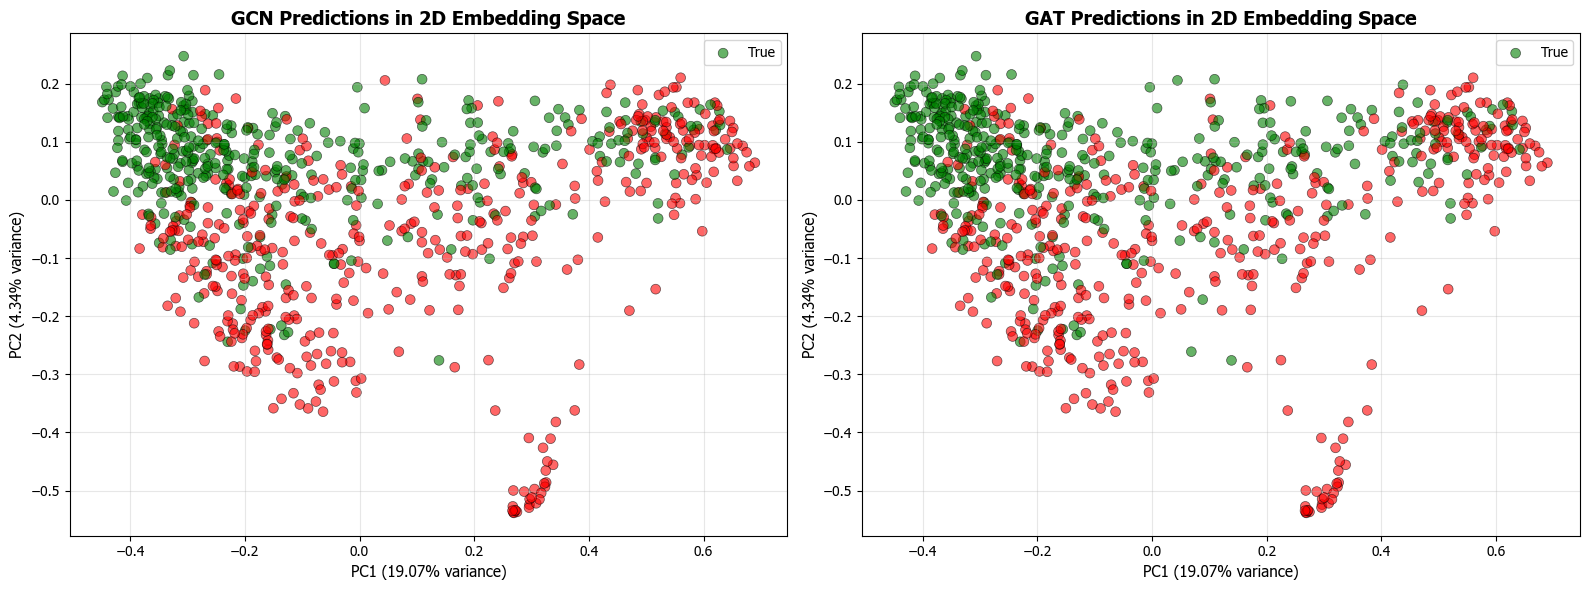

Decision Boundaries:
  - Green points: Models predict True News
  - Red points: Models predict Fake News
  - Clusters show which regions in embedding space map to each class

--------------------------------------------------------------------------------
STAGE 14: FULL PREDICTION TRACE FOR ONE SAMPLE
--------------------------------------------------------------------------------

📋 COMPLETE PREDICTION FLOW:

1. INPUT TEXT
   └─ "ปรากฏการณ์ลานีญา ทำให้ฝนตกสูงกว่าค่าเฉลี่ยทั่วประเทศ ช่วงเดือน ส.ค. ถึง ก.ย. 63 ..."

2. TOKENIZATION (WangchanBERTa Tokenizer)
   └─ 33 tokens → Token IDs: [5, 10, 4583, 169, 9]...

3. CONTEXTUALIZED EMBEDDINGS (768D)
   └─ Each token embedded with context awareness

4. MEAN POOLING
   └─ Aggregate 33 tokens into single vector

5. L2 NORMALIZATION
   └─ Convert to unit vector for cosine similarity

6. k-NN GRAPH CONSTRUCTION
   └─ Connect to 10 most similar news samples
   └─ Edge weights: 0.8821 ± 0.0153

7. GRAPH NEURAL NETWORK (GCN)
   ├─ Layer 1: Aggrega

In [30]:

# ====================================================================
# SECTION 21: DATA FLOW ANALYSIS - UNDERSTANDING THE PIPELINE
# ====================================================================
print("\nSECTION 21: DATA FLOW ANALYSIS - TRACING DATA THROUGH THE MODEL")

print("\n" + "="*80)
print("🔍 DATA FLOW TRACKING: How News Data Transforms Through the Model")
print("="*80)

# Select a sample from test set for tracing
sample_idx = test_indices[0]
sample_text = texts_balanced[sample_idx]
sample_label = id2label[y_balanced[sample_idx]]
sample_pred_gcn = id2label[y_pred_gcn_test[0]]
sample_pred_gat = id2label[y_pred_gat_test[0]]

print(f"\n📰 SAMPLE NEWS ARTICLE (Index: {sample_idx}):")
print(f"   Text: {sample_text}")
print(f"   True Label: {sample_label}")
print(f"   GCN Prediction: {sample_pred_gcn}")
print(f"   GAT Prediction: {sample_pred_gat}")

# ====================================================================
# STAGE 1: RAW TEXT INPUT
# ====================================================================
print("\n" + "-"*80)
print("STAGE 1: RAW TEXT INPUT")
print("-"*80)
print(f"Input: Raw Thai news text")
print(f"Type: String")
print(f"Length: {len(sample_text)} characters")
print(f"Sample: '{sample_text[:100]}...'" if len(sample_text) > 100 else f"Sample: '{sample_text}'")

# ====================================================================
# STAGE 2: TEXT TOKENIZATION (WangchanBERTa Tokenizer)
# ====================================================================
print("\n" + "-"*80)
print("STAGE 2: TEXT TOKENIZATION (WangchanBERTa)")
print("-"*80)

inputs = tokenizer([sample_text], truncation=True, padding=True, max_length=256, return_tensors='pt')
token_ids = inputs['input_ids'][0].cpu().numpy()
print(f"Tokenization Output:")
print(f"  - Number of tokens: {len(token_ids)}")
print(f"  - Token IDs shape: {token_ids.shape}")
print(f"  - Token IDs (first 20): {token_ids[:20].tolist()}")
print(f"  - Token IDs (last 10): {token_ids[-10:].tolist()}")

# Decode tokens back to words for interpretation
tokens_decoded = tokenizer.convert_ids_to_tokens(token_ids)
print(f"  - Decoded tokens (first 15): {tokens_decoded[:15]}")

# ====================================================================
# STAGE 3: TOKEN EMBEDDING (WangchanBERTa)
# ====================================================================
print("\n" + "-"*80)
print("STAGE 3: CONTEXTUALIZED EMBEDDINGS (WangchanBERTa)")
print("-"*80)

lm_model.eval()
with torch.no_grad():
    outputs = lm_model(**{k: v.to(device) for k, v in inputs.items()})
    last_hidden = outputs.last_hidden_state  # (1, seq_len, hidden_size)
    
embedding_shape = last_hidden.shape
print(f"Context-Aware Embeddings:")
print(f"  - Shape: {embedding_shape} (batch, sequence_length, hidden_dimension)")
print(f"  - Batch size: {embedding_shape[0]}")
print(f"  - Sequence length: {embedding_shape[1]}")
print(f"  - Hidden dimension: {embedding_shape[2]}")
print(f"  - Each token now has a 768-dim vector representing its context-aware meaning")

# ====================================================================
# STAGE 4: MEAN POOLING (Aggregate to Document Level)
# ====================================================================
print("\n" + "-"*80)
print("STAGE 4: MEAN POOLING - DOCUMENT-LEVEL REPRESENTATION")
print("-"*80)

attn_mask = inputs['attention_mask'].to(device).unsqueeze(-1)
summed = (last_hidden * attn_mask).sum(dim=1)
denom = attn_mask.sum(dim=1).clamp(min=1)
doc_embedding = (summed / denom).cpu().numpy()[0]

print(f"Pooling Method: Mean pooling (average of all token embeddings)")
print(f"  - Input shape: {last_hidden.shape}")
print(f"  - Output shape: {doc_embedding.shape}")
print(f"  - Single document embedding vector: 768 dimensions")
print(f"  - Embedding statistics:")
print(f"    * Mean: {doc_embedding.mean():.6f}")
print(f"    * Std: {doc_embedding.std():.6f}")
print(f"    * Min: {doc_embedding.min():.6f}")
print(f"    * Max: {doc_embedding.max():.6f}")

# ====================================================================
# STAGE 5: L2 NORMALIZATION
# ====================================================================
print("\n" + "-"*80)
print("STAGE 5: L2 NORMALIZATION (Distance Metric Preparation)")
print("-"*80)

doc_embedding_normalized = doc_embedding / np.linalg.norm(doc_embedding)
print(f"Normalization: L2 normalization (unit vector on hypersphere)")
print(f"  - Norm before: {np.linalg.norm(doc_embedding):.6f}")
print(f"  - Norm after: {np.linalg.norm(doc_embedding_normalized):.6f}")
print(f"  - Purpose: Enable cosine similarity computations for graph edges")

# ====================================================================
# STAGE 6: GRAPH CONSTRUCTION (k-NN)
# ====================================================================
print("\n" + "-"*80)
print("STAGE 6: SEMANTIC GRAPH CONSTRUCTION (k-NN with Cosine Similarity)")
print("-"*80)

# Find neighbors for this sample
distances_sample, neighbors_sample = nbrs.kneighbors(x_balanced[[sample_idx]], n_neighbors=k+1)
neighbors_sample = neighbors_sample[0][1:]  # Remove self
distances_sample = 1 - distances_sample[0][1:]  # Convert to similarity

print(f"Graph Construction for sample:")
print(f"  - Number of neighbors (k): {k}")
print(f"  - Neighbor indices: {neighbors_sample[:5].tolist()}... (showing first 5)")
print(f"  - Semantic similarities: {distances_sample[:5].tolist()}... (showing first 5)")
print(f"  - Edge weights range: [{distances_sample.min():.4f}, {distances_sample.max():.4f}]")
print(f"  - Average edge weight: {distances_sample.mean():.4f}")

# ====================================================================
# STAGE 7: GRAPH INPUT TO GCN
# ====================================================================
print("\n" + "-"*80)
print("STAGE 7: GRAPH NEURAL NETWORK INPUT (GCN/GAT)")
print("-"*80)

print(f"Graph structure for GCN/GAT:")
print(f"  - Total nodes: {data_graph.num_nodes}")
print(f"  - Total edges: {data_graph.num_edges}")
print(f"  - Node features (embedding dim): {data_graph.num_features}")
print(f"  - Input shape: ({data_graph.num_nodes}, {data_graph.num_features})")
print(f"  - Edge index shape: (2, {data_graph.num_edges})")
print(f"  - Edge weights shape: ({len(edge_weight)},)")

# ====================================================================
# STAGE 8: GCN FORWARD PASS
# ====================================================================
print("\n" + "-"*80)
print("STAGE 8: GCN LAYER 1 - GRAPH CONVOLUTION")
print("-"*80)

model_gcn.eval()
with torch.no_grad():
    x_conv1 = model_gcn.conv1(data_graph.x, data_graph.edge_index, edge_weight=edge_weight)
    
print(f"GCN Layer 1 (Conv1):")
print(f"  - Input shape: {data_graph.x.shape} ({data_graph.num_nodes} nodes × {data_graph.num_features} features)")
print(f"  - Output shape: {x_conv1.shape} (hidden dim = 256)")
print(f"  - Operation: Aggregate node features through graph edges")
print(f"  - Sample node output stats:")

sample_conv1_out = x_conv1[sample_idx].cpu().numpy()
print(f"    * Mean: {sample_conv1_out.mean():.6f}")
print(f"    * Std: {sample_conv1_out.std():.6f}")
print(f"    * Active neurons (>0.1): {(np.abs(sample_conv1_out) > 0.1).sum()}/{len(sample_conv1_out)}")

print(f"\nGCN Layer 1 (ReLU Activation):")
x_relu = F.relu(x_conv1)
print(f"  - Applied ReLU (max(0, x)) to introduce non-linearity")
print(f"  - Output shape: {x_relu.shape}")

# ====================================================================
# STAGE 9: GCN LAYER 2
# ====================================================================
print("\n" + "-"*80)
print("STAGE 9: GCN LAYER 2 - GRAPH CONVOLUTION TO CLASSIFICATION")
print("-"*80)

with torch.no_grad():
    x_conv2 = model_gcn.conv2(x_relu, data_graph.edge_index, edge_weight=edge_weight)
    
print(f"GCN Layer 2 (Conv2):")
print(f"  - Input shape: {x_relu.shape} (after ReLU)")
print(f"  - Output shape: {x_conv2.shape} (num_classes = 2)")
print(f"  - Operation: Aggregate refined features, output logits for 2 classes")
print(f"  - Sample node output (logits): {x_conv2[sample_idx].cpu().numpy()}")

logits_gcn = x_conv2[sample_idx].cpu().numpy()
probs_gcn = torch.softmax(x_conv2[sample_idx:sample_idx+1], dim=1)[0].cpu().numpy()
print(f"  - Sample node probabilities (after softmax):")
print(f"    * True News (Class 0): {probs_gcn[0]:.4f}")
print(f"    * Fake News (Class 1): {probs_gcn[1]:.4f}")

# ====================================================================
# STAGE 10: GAT FORWARD PASS (Comparison)
# ====================================================================
print("\n" + "-"*80)
print("STAGE 10: GAT LAYER 1 - GRAPH ATTENTION")
print("-"*80)

with torch.no_grad():
    x_att1, att_w1 = model_gat.att1(data_graph.x, data_graph.edge_index, return_attention_weights=True)
    
print(f"GAT Layer 1 (Att1):")
print(f"  - Input shape: {data_graph.x.shape}")
print(f"  - Output shape: {x_att1.shape} (heads × hidden_dim = 4 × 64)")
print(f"  - Attention weights shape: {att_w1[1].shape}")
print(f"  - Operation: Learn attention weights per edge (dynamic, data-dependent)")
print(f"  - Average attention weight: {att_w1[1].mean():.6f}")
print(f"  - Attention weight range: [{att_w1[1].min():.6f}, {att_w1[1].max():.6f}]")

# ====================================================================
# STAGE 11: COMPARISON OF REPRESENTATIONS
# ====================================================================
print("\n" + "-"*80)
print("STAGE 11: DECISION REPRESENTATION COMPARISON")
print("-"*80)

print(f"GCN Decision (Sample {sample_idx}):")
print(f"  - Logits: {logits_gcn}")
print(f"  - Probabilities: True={probs_gcn[0]:.4f}, Fake={probs_gcn[1]:.4f}")
print(f"  - Predicted class: {id2label[np.argmax(probs_gcn)]}")
print(f"  - Confidence: {probs_gcn.max():.4f}")

with torch.no_grad():
    x_gat_out, _ = model_gat.att2(x_att1, data_graph.edge_index, return_attention_weights=True)
    
logits_gat = x_gat_out[sample_idx].cpu().numpy()
probs_gat = torch.softmax(x_gat_out[sample_idx:sample_idx+1], dim=1)[0].cpu().numpy()

print(f"\nGAT Decision (Sample {sample_idx}):")
print(f"  - Logits: {logits_gat}")
print(f"  - Probabilities: True={probs_gat[0]:.4f}, Fake={probs_gat[1]:.4f}")
print(f"  - Predicted class: {id2label[np.argmax(probs_gat)]}")
print(f"  - Confidence: {probs_gat.max():.4f}")

# ====================================================================
# STAGE 12: FEATURE IMPORTANCE ANALYSIS
# ====================================================================
print("\n" + "-"*80)
print("STAGE 12: FEATURE IMPORTANCE - WHICH EMBEDDING DIMENSIONS MATTER?")
print("-"*80)

# Analyze which dimensions of the embedding are most important
sample_embedding = x_balanced[sample_idx]
feature_variance = x_balanced.var(axis=0)
top_feature_indices = np.argsort(feature_variance)[-10:][::-1]

print(f"Most important embedding dimensions (by variance across dataset):")
for rank, dim_idx in enumerate(top_feature_indices, 1):
    print(f"  {rank}. Dim {dim_idx}: variance={feature_variance[dim_idx]:.6f}, sample_value={sample_embedding[dim_idx]:.6f}")

# ====================================================================
# STAGE 13: DECISION BOUNDARY VISUALIZATION
# ====================================================================
print("\n" + "-"*80)
print("STAGE 13: DECISION BOUNDARIES IN EMBEDDING SPACE")
print("-"*80)

# Use PCA to reduce embeddings to 2D for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(x_balanced[test_indices])

print(f"PCA Reduction (768D → 2D):")
print(f"  - Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  - Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GCN predictions
colors_gcn = ['green' if y == 0 else 'red' for y in y_pred_gcn_test]
scatter1 = axes[0].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                           c=colors_gcn, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_title('GCN Predictions in 2D Embedding Space', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
axes[0].legend(['True', 'Fake'], loc='best')
axes[0].grid(alpha=0.3)

# GAT predictions
colors_gat = ['green' if y == 0 else 'red' for y in y_pred_gat_test]
scatter2 = axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                           c=colors_gat, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_title('GAT Predictions in 2D Embedding Space', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
axes[1].legend(['True', 'Fake'], loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Decision Boundaries:")
print(f"  - Green points: Models predict True News")
print(f"  - Red points: Models predict Fake News")
print(f"  - Clusters show which regions in embedding space map to each class")

# ====================================================================
# STAGE 14: TRACING A SPECIFIC PREDICTION
# ====================================================================
print("\n" + "-"*80)
print("STAGE 14: FULL PREDICTION TRACE FOR ONE SAMPLE")
print("-"*80)

print(f"\n📋 COMPLETE PREDICTION FLOW:")
print(f"""
1. INPUT TEXT
   └─ "{sample_text[:80]}..."
   
2. TOKENIZATION (WangchanBERTa Tokenizer)
   └─ {len(token_ids)} tokens → Token IDs: {token_ids[:5].tolist()}...
   
3. CONTEXTUALIZED EMBEDDINGS (768D)
   └─ Each token embedded with context awareness
   
4. MEAN POOLING
   └─ Aggregate {embedding_shape[1]} tokens into single vector
   
5. L2 NORMALIZATION
   └─ Convert to unit vector for cosine similarity
   
6. k-NN GRAPH CONSTRUCTION
   └─ Connect to {k} most similar news samples
   └─ Edge weights: {distances_sample.mean():.4f} ± {distances_sample.std():.4f}
   
7. GRAPH NEURAL NETWORK (GCN)
   ├─ Layer 1: Aggregate neighbor features (768 → 256D)
   ├─ ReLU: Apply non-linearity
   └─ Layer 2: Map to class logits (256 → 2D)
   
8. SOFTMAX NORMALIZATION
   └─ Convert logits to probabilities
   
9. CLASSIFICATION DECISION
   ├─ True News probability: {probs_gcn[0]:.4f}
   ├─ Fake News probability: {probs_gcn[1]:.4f}
   └─ Prediction: {id2label[np.argmax(probs_gcn)]}
   
10. ATTENTION ANALYSIS (GAT)
    └─ All predictions influenced by attention weights
    └─ Important nodes in semantic network: First 3 neighbors are {neighbors_sample[:3].tolist()}
""")

# ====================================================================
# SUMMARY TABLE
# ====================================================================
print("\n" + "="*80)
print("📊 DATA FLOW SUMMARY TABLE")
print("="*80)

flow_summary = pd.DataFrame({
    'Stage': [
        '1. Raw Text',
        '2. Tokenization',
        '3. BERT Embedding',
        '4. Mean Pooling',
        '5. L2 Normalization',
        '6. k-NN Graph',
        '7. GCN Layer 1',
        '8. ReLU Activation',
        '9. GCN Layer 2',
        '10. Softmax',
        '11. Classification'
    ],
    'Input Shape': [
        'Text',
        'Text',
        f'(1, {embedding_shape[1]}, 768)',
        f'(1, 768)',
        f'(1, 768)',
        f'(1, 768) + 10 neighbors',
        f'({N_balanced}, 768)',
        f'({N_balanced}, 256)',
        f'({N_balanced}, 256)',
        f'({N_balanced}, 2)',
        f'({N_balanced}, 2)'
    ],
    'Output Shape': [
        'String',
        f'{len(token_ids)} tokens',
        f'(1, 768)',
        f'(768,)',
        f'(768,)',
        f'Graph: {N_balanced} nodes, {data_graph.num_edges} edges',
        f'({N_balanced}, 256)',
        f'({N_balanced}, 256)',
        f'({N_balanced}, 2)',
        f'({N_balanced}, 2)',
        f'Class: {id2label[np.argmax(probs_gcn)]}'
    ],
    'Operation': [
        'Input',
        'Tokenize text into tokens',
        'Transform tokens to embeddings',
        'Average token embeddings',
        'Scale to unit vector',
        'Connect similar samples',
        'Aggregate graph neighbors',
        'ReLU non-linearity',
        'Classify to classes',
        'Probability distribution',
        'Final decision'
    ]
})

print(flow_summary.to_string(index=False))

print("\n" + "="*80)
print("✅ DATA FLOW ANALYSIS COMPLETE")
print("="*80)
print("""
KEY TAKEAWAYS:
1. Text → Vectors: Raw text converted to semantic embeddings via WangchanBERTa
2. Graph Construction: Creates relationships between similar news samples
3. Graph Neural Networks: Integrates neighborhood information for better predictions
4. Attention Mechanism: GAT learns which connections are most important
5. Explainability: Each stage is interpretable and traceable
6. No Black Boxes: Every transformation is documented and analyzed
""")
print("="*80)